# Preliminary Statistical Analysis: GDELT Data

This notebook provides a first-pass statistical analysis for daily GDELT features in the filled dataset:
- data loading and validation,
- data quality checks,
- descriptive statistics,
- distribution and temporal pattern visualization,
- autocorrelation diagnostics.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

In [2]:
data_candidates = [
    Path("../data/equity_data/gdelt_data_dailt_filled.csv"),
    Path("../data/equity_data/gdelt_data_daily_filled.csv"),
    Path("data/equity_data/gdelt_data_dailt_filled.csv"),
    Path("data/equity_data/gdelt_data_daily_filled.csv"),
]

data_path = next((p for p in data_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not locate the filled GDELT CSV file from current working directory.")

df = pd.read_csv(data_path)

date_col = "Date" if "Date" in df.columns else ("date" if "date" in df.columns else None)
if date_col is None:
    raise ValueError("Date column not found. Expected `Date` or `date`.")

if date_col != "Date":
    df = df.rename(columns={date_col: "Date"})

numeric_cols = [c for c in df.columns if c != "Date"]

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values("Date").reset_index(drop=True)

print(f"Data source: {data_path}")
print(f"Rows: {len(df):,}, Columns: {len(df.columns)}")
print(f"Numeric features: {numeric_cols}")
display(df.head())

Data source: ..\data\equity_data\gdelt_data_daily_filled.csv
Rows: 1,097, Columns: 4
Numeric features: ['gdelt_articles', 'gdelt_robust', 'sentiment_score']


,Date,gdelt_articles,gdelt_robust,sentiment_score
0,2023-01-01,0.3065,-0.224062,-0.9249
1,2023-01-02,0.4465,0.548565,-0.7794
2,2023-01-03,0.8445,2.745033,-0.9603
3,2023-01-04,0.8318,2.674945,-1.7953
4,2023-01-05,0.5053,0.873068,-1.3037


In [3]:
quality_report = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique_values": df.nunique(dropna=True),
    }
)

date_range = (df["Date"].min(), df["Date"].max())
duplicate_rows = int(df.duplicated().sum())
duplicate_dates = int(df["Date"].duplicated().sum())

full_calendar = pd.date_range(start=date_range[0], end=date_range[1], freq="D")
missing_dates = full_calendar.difference(df["Date"].dropna())

display(quality_report)
print(f"Date range: {date_range[0].date()} -> {date_range[1].date()}")
print(f"Duplicate rows: {duplicate_rows}")
print(f"Duplicate dates: {duplicate_dates}")
print(f"Missing calendar dates: {len(missing_dates)}")

if len(missing_dates) > 0:
    print("First missing dates:", [d.date() for d in missing_dates[:10]])

,dtype,missing_values,missing_pct,unique_values
Date,datetime64[us],0,0.0,1097
gdelt_articles,float64,0,0.0,984
gdelt_robust,float64,0,0.0,987
sentiment_score,float64,0,0.0,1070


Date range: 2023-01-01 -> 2026-01-01
Duplicate rows: 0
Duplicate dates: 0
Missing calendar dates: 0


In [4]:
percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
base_stats = df[numeric_cols].describe(percentiles=percentiles).T

extra_stats = pd.DataFrame(
    {
        "variance": df[numeric_cols].var(),
        "IQR": df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25),
        "skewness": df[numeric_cols].skew(),
        "kurtosis": df[numeric_cols].kurt(),
        "coef_of_variation": df[numeric_cols].std() / df[numeric_cols].mean().replace(0, np.nan),
    }
)

stats_table = base_stats.join(extra_stats).round(4)
display(stats_table)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,variance,IQR,skewness,kurtosis,coef_of_variation
gdelt_articles,1097.0,0.3940,0.1829,0.1552,0.1725,0.2030,0.2809,0.3577,0.4545,0.7224,0.9835,2.5457,0.0335,0.1736,3.4065,25.6810,0.4642
gdelt_robust,1097.0,0.2591,1.0095,-1.0591,-0.9636,-0.7953,-0.3654,0.0585,0.5927,2.0710,3.5119,12.1336,1.0190,0.9581,3.4065,25.6810,3.8963
sentiment_score,1097.0,-0.3812,0.6336,-3.5467,-2.5255,-1.5485,-0.6766,-0.2938,0.0288,0.4702,0.8272,1.3550,0.4014,0.7054,-1.0658,2.1919,-1.6620


,gdelt_articles,gdelt_robust,sentiment_score
gdelt_articles,1.0000,1.0000,-0.4689
gdelt_robust,1.0000,1.0000,-0.4689
sentiment_score,-0.4689,-0.4689,1.0000


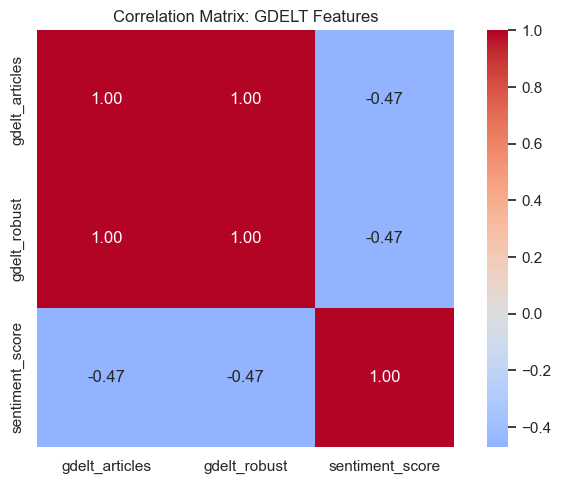

In [5]:
corr = df[numeric_cols].corr(method="pearson")
display(corr.round(4))

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix: GDELT Features")
plt.tight_layout()
plt.show()

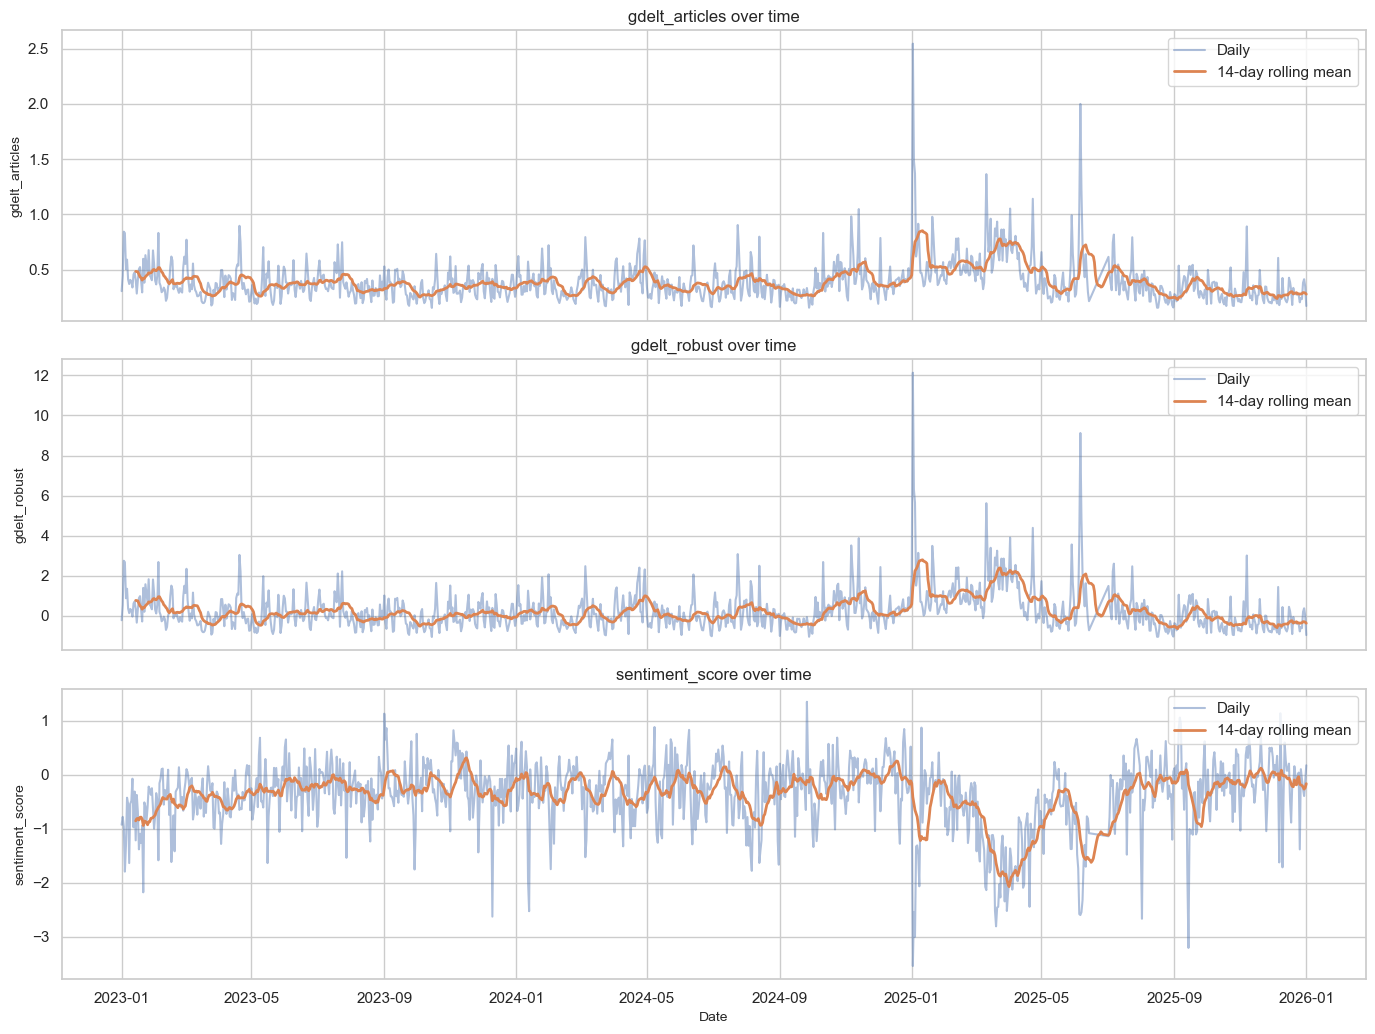

In [6]:
rolling_window = 14
rolling_means = df[numeric_cols].rolling(rolling_window).mean()

n = len(numeric_cols)
fig, axes = plt.subplots(n, 1, figsize=(14, 3.5 * n), sharex=True)
if n == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.plot(df["Date"], df[col], alpha=0.45, label="Daily")
    ax.plot(df["Date"], rolling_means[col], linewidth=2, label=f"{rolling_window}-day rolling mean")
    ax.set_title(f"{col} over time")
    ax.set_ylabel(col)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

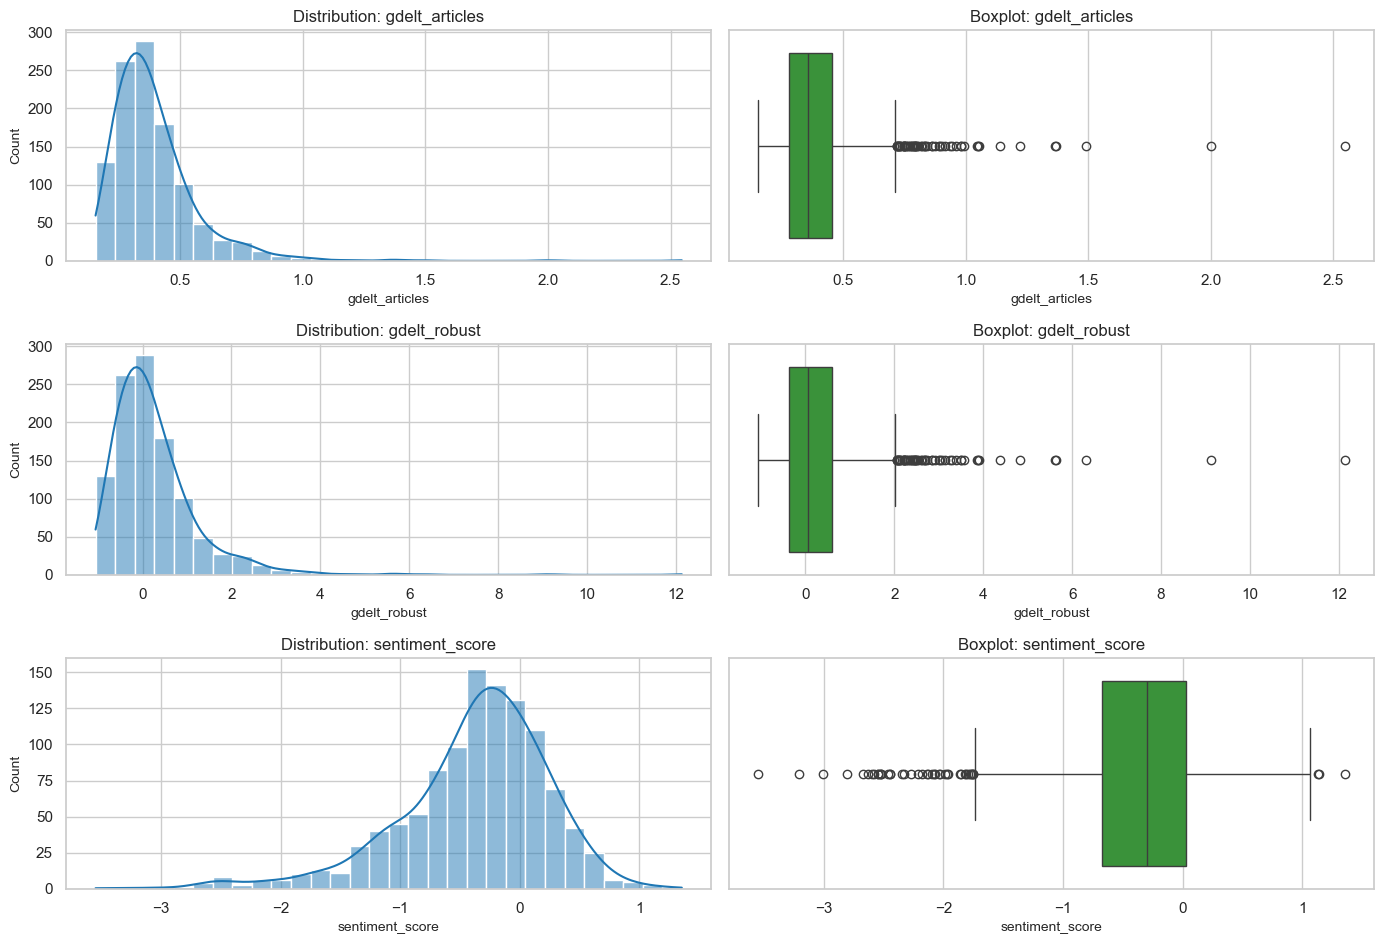

In [7]:
n = len(numeric_cols)
fig, axes = plt.subplots(n, 2, figsize=(14, 3.2 * n))
if n == 1:
    axes = np.array([axes])

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i, 0], color="tab:blue")
    axes[i, 0].set_title(f"Distribution: {col}")
    axes[i, 0].set_xlabel(col)

    sns.boxplot(x=df[col], ax=axes[i, 1], color="tab:green")
    axes[i, 1].set_title(f"Boxplot: {col}")
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

,gdelt_articles,gdelt_robust,sentiment_score
weekday,,,
Monday,0.4022,0.3041,-0.3134
Tuesday,0.4306,0.4610,-0.4308
Wednesday,0.4392,0.5084,-0.4048
Thursday,0.4309,0.4625,-0.3340
Friday,0.4171,0.3864,-0.3563
Saturday,0.3362,-0.0604,-0.4856
Sunday,0.3019,-0.2495,-0.3440


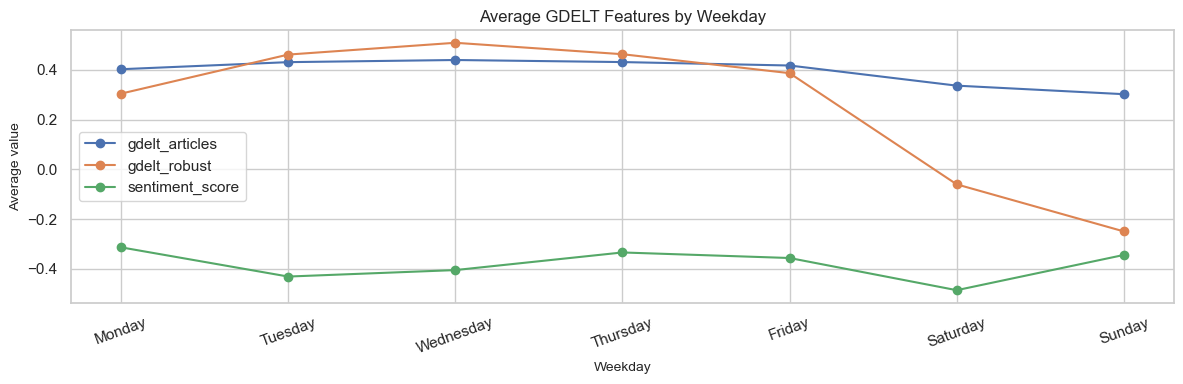

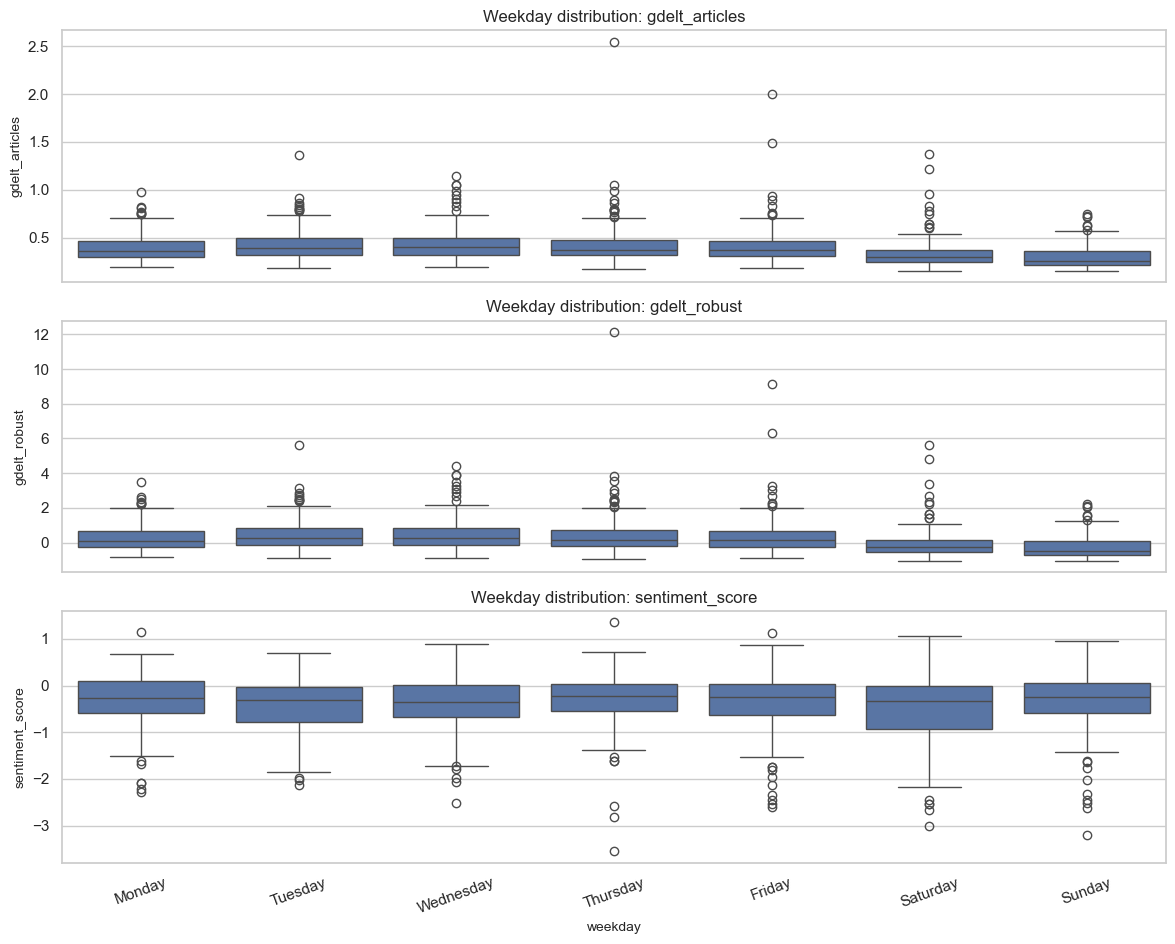

In [8]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["weekday"] = df["Date"].dt.day_name()

weekday_summary = (
    df.groupby("weekday")[numeric_cols]
    .mean()
    .reindex(weekday_order)
    .round(4)
)
display(weekday_summary)

plt.figure(figsize=(12, 4))
for col in numeric_cols:
    plt.plot(weekday_summary.index, weekday_summary[col], marker="o", label=col)
plt.title("Average GDELT Features by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average value")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

n = len(numeric_cols)
fig, axes = plt.subplots(n, 1, figsize=(12, 3.2 * n), sharex=True)
if n == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x="weekday", y=col, order=weekday_order, ax=axes[i])
    axes[i].set_title(f"Weekday distribution: {col}")
    axes[i].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

,gdelt_articles,gdelt_robust,sentiment_score
Date,,,
2025-02-28,0.5431,1.0815,-0.5824
2025-03-31,0.6741,1.8047,-1.6299
2025-04-30,0.5611,1.1811,-1.2774
2025-05-31,0.3699,0.1258,-0.5387
2025-06-30,0.5158,0.9308,-1.3244
2025-07-31,0.4299,0.4568,-0.2167
2025-08-31,0.2861,-0.3364,-0.2545
2025-09-30,0.3585,0.0631,-0.3668
2025-10-31,0.2889,-0.3210,-0.1414


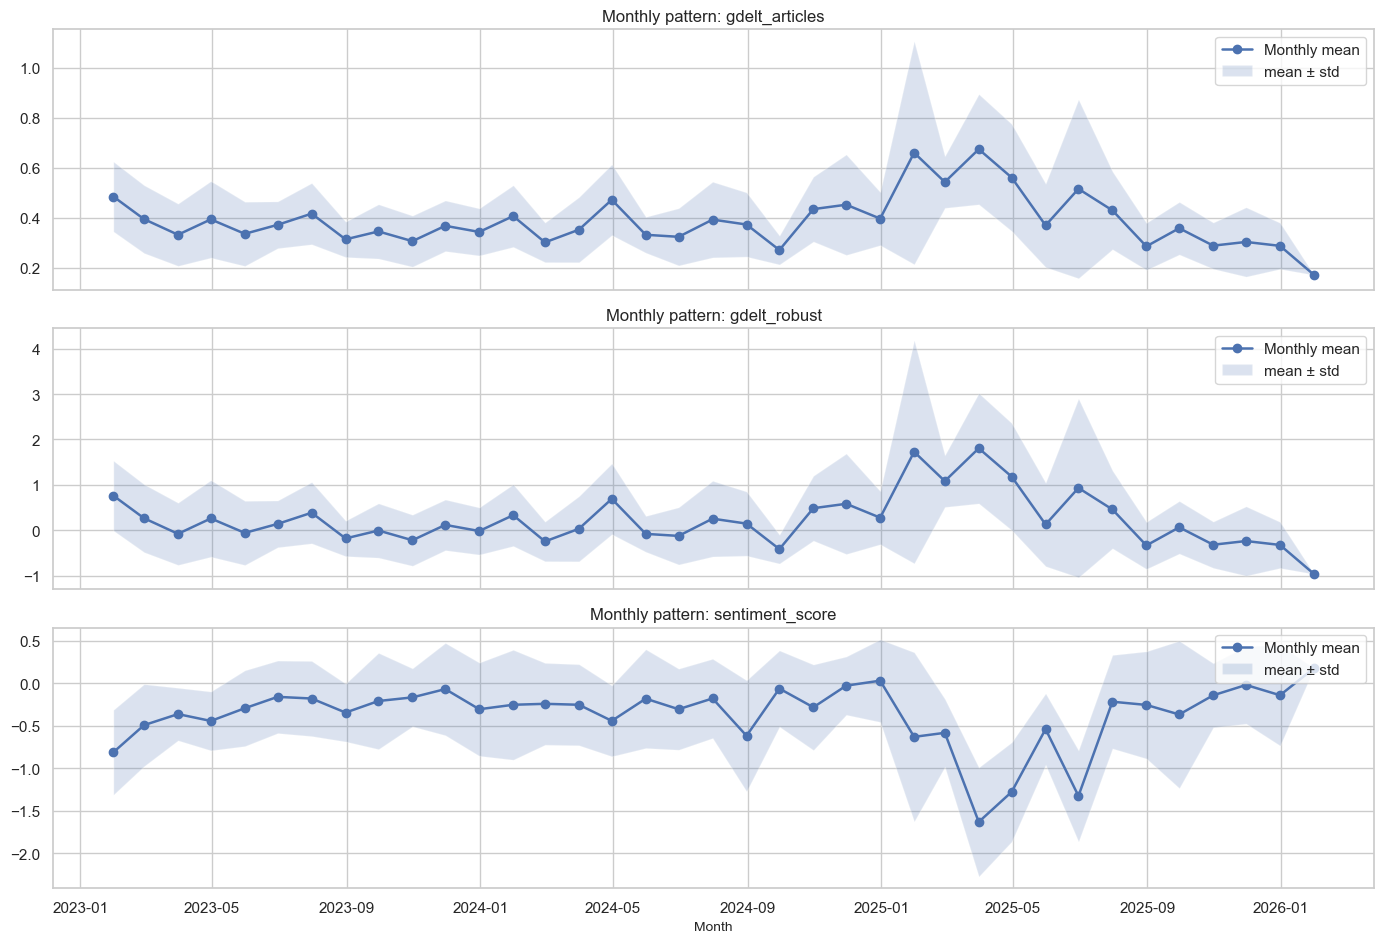

In [9]:
monthly_mean = df.set_index("Date")[numeric_cols].resample("ME").mean()
monthly_std = df.set_index("Date")[numeric_cols].resample("ME").std()

display(monthly_mean.tail(12).round(4))

n = len(numeric_cols)
fig, axes = plt.subplots(n, 1, figsize=(14, 3.2 * n), sharex=True)
if n == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.plot(monthly_mean.index, monthly_mean[col], marker="o", linewidth=1.8, label="Monthly mean")
    lower = monthly_mean[col] - monthly_std[col].fillna(0)
    upper = monthly_mean[col] + monthly_std[col].fillna(0)
    ax.fill_between(monthly_mean.index, lower, upper, alpha=0.2, label="mean ± std")
    ax.set_title(f"Monthly pattern: {col}")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Month")
plt.tight_layout()
plt.show()

,gdelt_articles,gdelt_robust,sentiment_score
lag,,,
1,0.6277,0.6277,0.5877
2,0.3841,0.3841,0.3938
3,0.2644,0.2644,0.3789
4,0.2545,0.2545,0.3593
5,0.2478,0.2478,0.3312
6,0.2763,0.2763,0.2790
7,0.2967,0.2967,0.2521
8,0.2502,0.2502,0.2367
9,0.1877,0.1877,0.2435


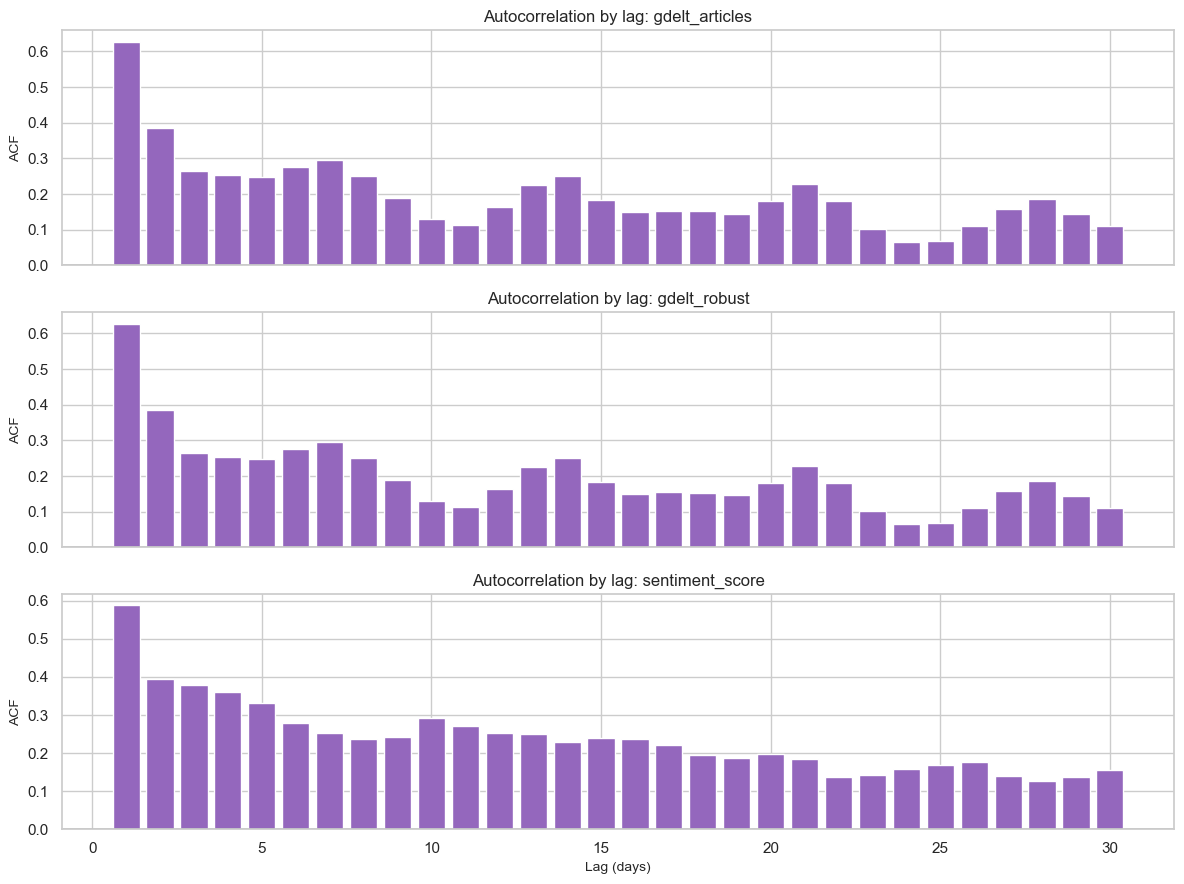

First-difference summary:


,count,mean,std,min,25%,50%,75%,max
gdelt_articles,1096.0,-0.0001,0.1579,-1.0562,-0.0706,-0.0036,0.0697,1.8211
gdelt_robust,1096.0,-0.0007,0.8712,-5.8289,-0.3893,-0.0199,0.3845,10.0502
sentiment_score,1096.0,0.0010,0.5753,-2.9339,-0.2912,0.0033,0.3154,2.7658


In [10]:
max_lag = 30
autocorr_table = pd.DataFrame(
    {
        col: [df[col].autocorr(lag=lag) for lag in range(1, max_lag + 1)]
        for col in numeric_cols
    },
    index=range(1, max_lag + 1),
)
autocorr_table.index.name = "lag"

display(autocorr_table.head(10).round(4))

n = len(numeric_cols)
fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True)
if n == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.bar(autocorr_table.index, autocorr_table[col], color="tab:purple")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Autocorrelation by lag: {col}")
    ax.set_ylabel("ACF")

axes[-1].set_xlabel("Lag (days)")
plt.tight_layout()
plt.show()

diff_summary = df[numeric_cols].diff().describe().T.round(4)
print("First-difference summary:")
display(diff_summary)

## Preliminary interpretation checklist

After running all cells, summarize:
- whether the series is complete and clean (missing dates, duplicates, nulls),
- which feature has the highest dispersion and strongest outlier behavior,
- whether weekly or monthly seasonality appears in any metric,
- whether autocorrelation suggests short-memory structure useful for lag features.

This is a lightweight exploratory notebook and can be extended with formal stationarity tests and decomposition.